In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.metrics import calculate_coalescent_information_ratio_at_MAP, calculate_rel_mean_shift, calculate_rel_mean_shift_const, calculate_rel_mode_shift, calculate_rel_median_shift, calculate_wasserstein_dist, calculate_wasserstein2_dist, calculate_mode_shift, calculate_median_shift
from src.evaluate_prior_impact import create_prior_influence_metric_df_const, create_prior_influence_metric_df_exp, create_prior_influence_metric_df_bottleneck, create_prior_influence_metric_df_const_pathogen, create_prior_influence_metric_df_pathogen_exp, create_prior_influence_metric_df_exp_pathogen, create_prior_influence_metric_df_bottleneck_pathogen
from src.prob_functions import likelihood_tMRCA_mutations, coalescent_prior, coalescent_prior_bottleneck, coalescent_prior_expN_present, coalescent_prior_expN
from src.plotting.plot_prob_functions import plot_tMRCA_constN, plot_tMRCA_expN_present, plot_tMRCA_expN, plot_tMRCA_bottleneck
from src.plotting.plot_metric_comparison import plot_error_metrics_const, plot_error_metrics_exp, plot_bottleneck_error_metrics_by_depth, plot_bottleneck_error_metrics_by_duration, plot_bottleneck_heatmaps, plot_error_heatmaps, plot_error_metrics_by_beta, plot_error_metrics_exp_all_metrics_per_subplot, plot_metrics_by_alpha_const, plot_error_metrics_by_beta_pathogen, plot_mode_shift_pathogen_summary, plot_metric_summary, plot_pathogen_error_summary

Expected time to MRCA:
$$
\hat{t}_{MRCA} = \frac{k}{\lambda} = \frac{k}{2\mu L}
$$

Simulation study settings - medium signal is like tuberculosis:
- mutation rate 4.6e-8
- genome length: 1e7, 5e6, 1e6
- mutations per genome, per year:
    - high signal: 0.46
    - mid signal: 0.23
    - low signal: 0.046

Influenza HA gene: 
- mutation rate: 3.5e-3
- genome length: 1768
- mutations per genome, per year: 6.188

Pertussis:
- mutation rate: 2.7 × 10–7 substitutions/site/year (highest posterior density [HPD] 2.4–3 × 10–7 substitutions/site/year)
- genome length: 4.1e6 bp
- mutations per genome, per year: 4.1e6 * 2.7e-7 = 1.107

In [17]:
L = 5e6
base_mu = 1e-6
print(f"Base mutations per genome per year: {base_mu * L}")
N_values = [10, 100, 1000, 10000, 100000]  # Rows
alpha_values = [0.01, 0.1, 1, 10]  # Columns
base_k = 200
t_max = 500  # Maximum tMRCA to consider

print(f"Exptected tMRCA based on likelihood only in years: {base_k / (2 * base_mu * L)}")
t_MRCA_exp = 20
print(f"Choose k: {2 * base_mu * L * t_MRCA_exp}")

Base mutations per genome per year: 5.0
Exptected tMRCA based on likelihood only in years: 20.0
Choose k: 200.0


In [19]:
# later sarscov 2 example

exp_tmrca = 0.6 #years
mutation_rate = 25 #per genome per year = mu * L

k = 2 * exp_tmrca * mutation_rate # 30

variance_sarscov = (k+1) / (2 * mutation_rate)**2
print(f"Variance for Sars-CoV-2: {variance_sarscov}")

# base case

variance_base = (base_k + 1) / (2 * base_mu * L)**2
print(f"Variance for base case: {variance_base / alpha_values[0]} - 0.05 mutations per genome per year")
print(f"Variance for base case: {variance_base / alpha_values[1]} - 0.5 mutations per genome per year")
print(f"Variance for base case: {variance_base / alpha_values[2]} - 5 mutations per genome per year, RNA Virus")
print(f"Variance for base case: {variance_base / alpha_values[3]} - 50 mutations per genome per year")


Variance for Sars-CoV-2: 0.0124
Variance for base case: 200.99999999999997 - 0.05 mutations per genome per year
Variance for base case: 20.099999999999998 - 0.5 mutations per genome per year
Variance for base case: 2.01 - 5 mutations per genome per year, RNA Virus
Variance for base case: 0.20099999999999998 - 50 mutations per genome per year


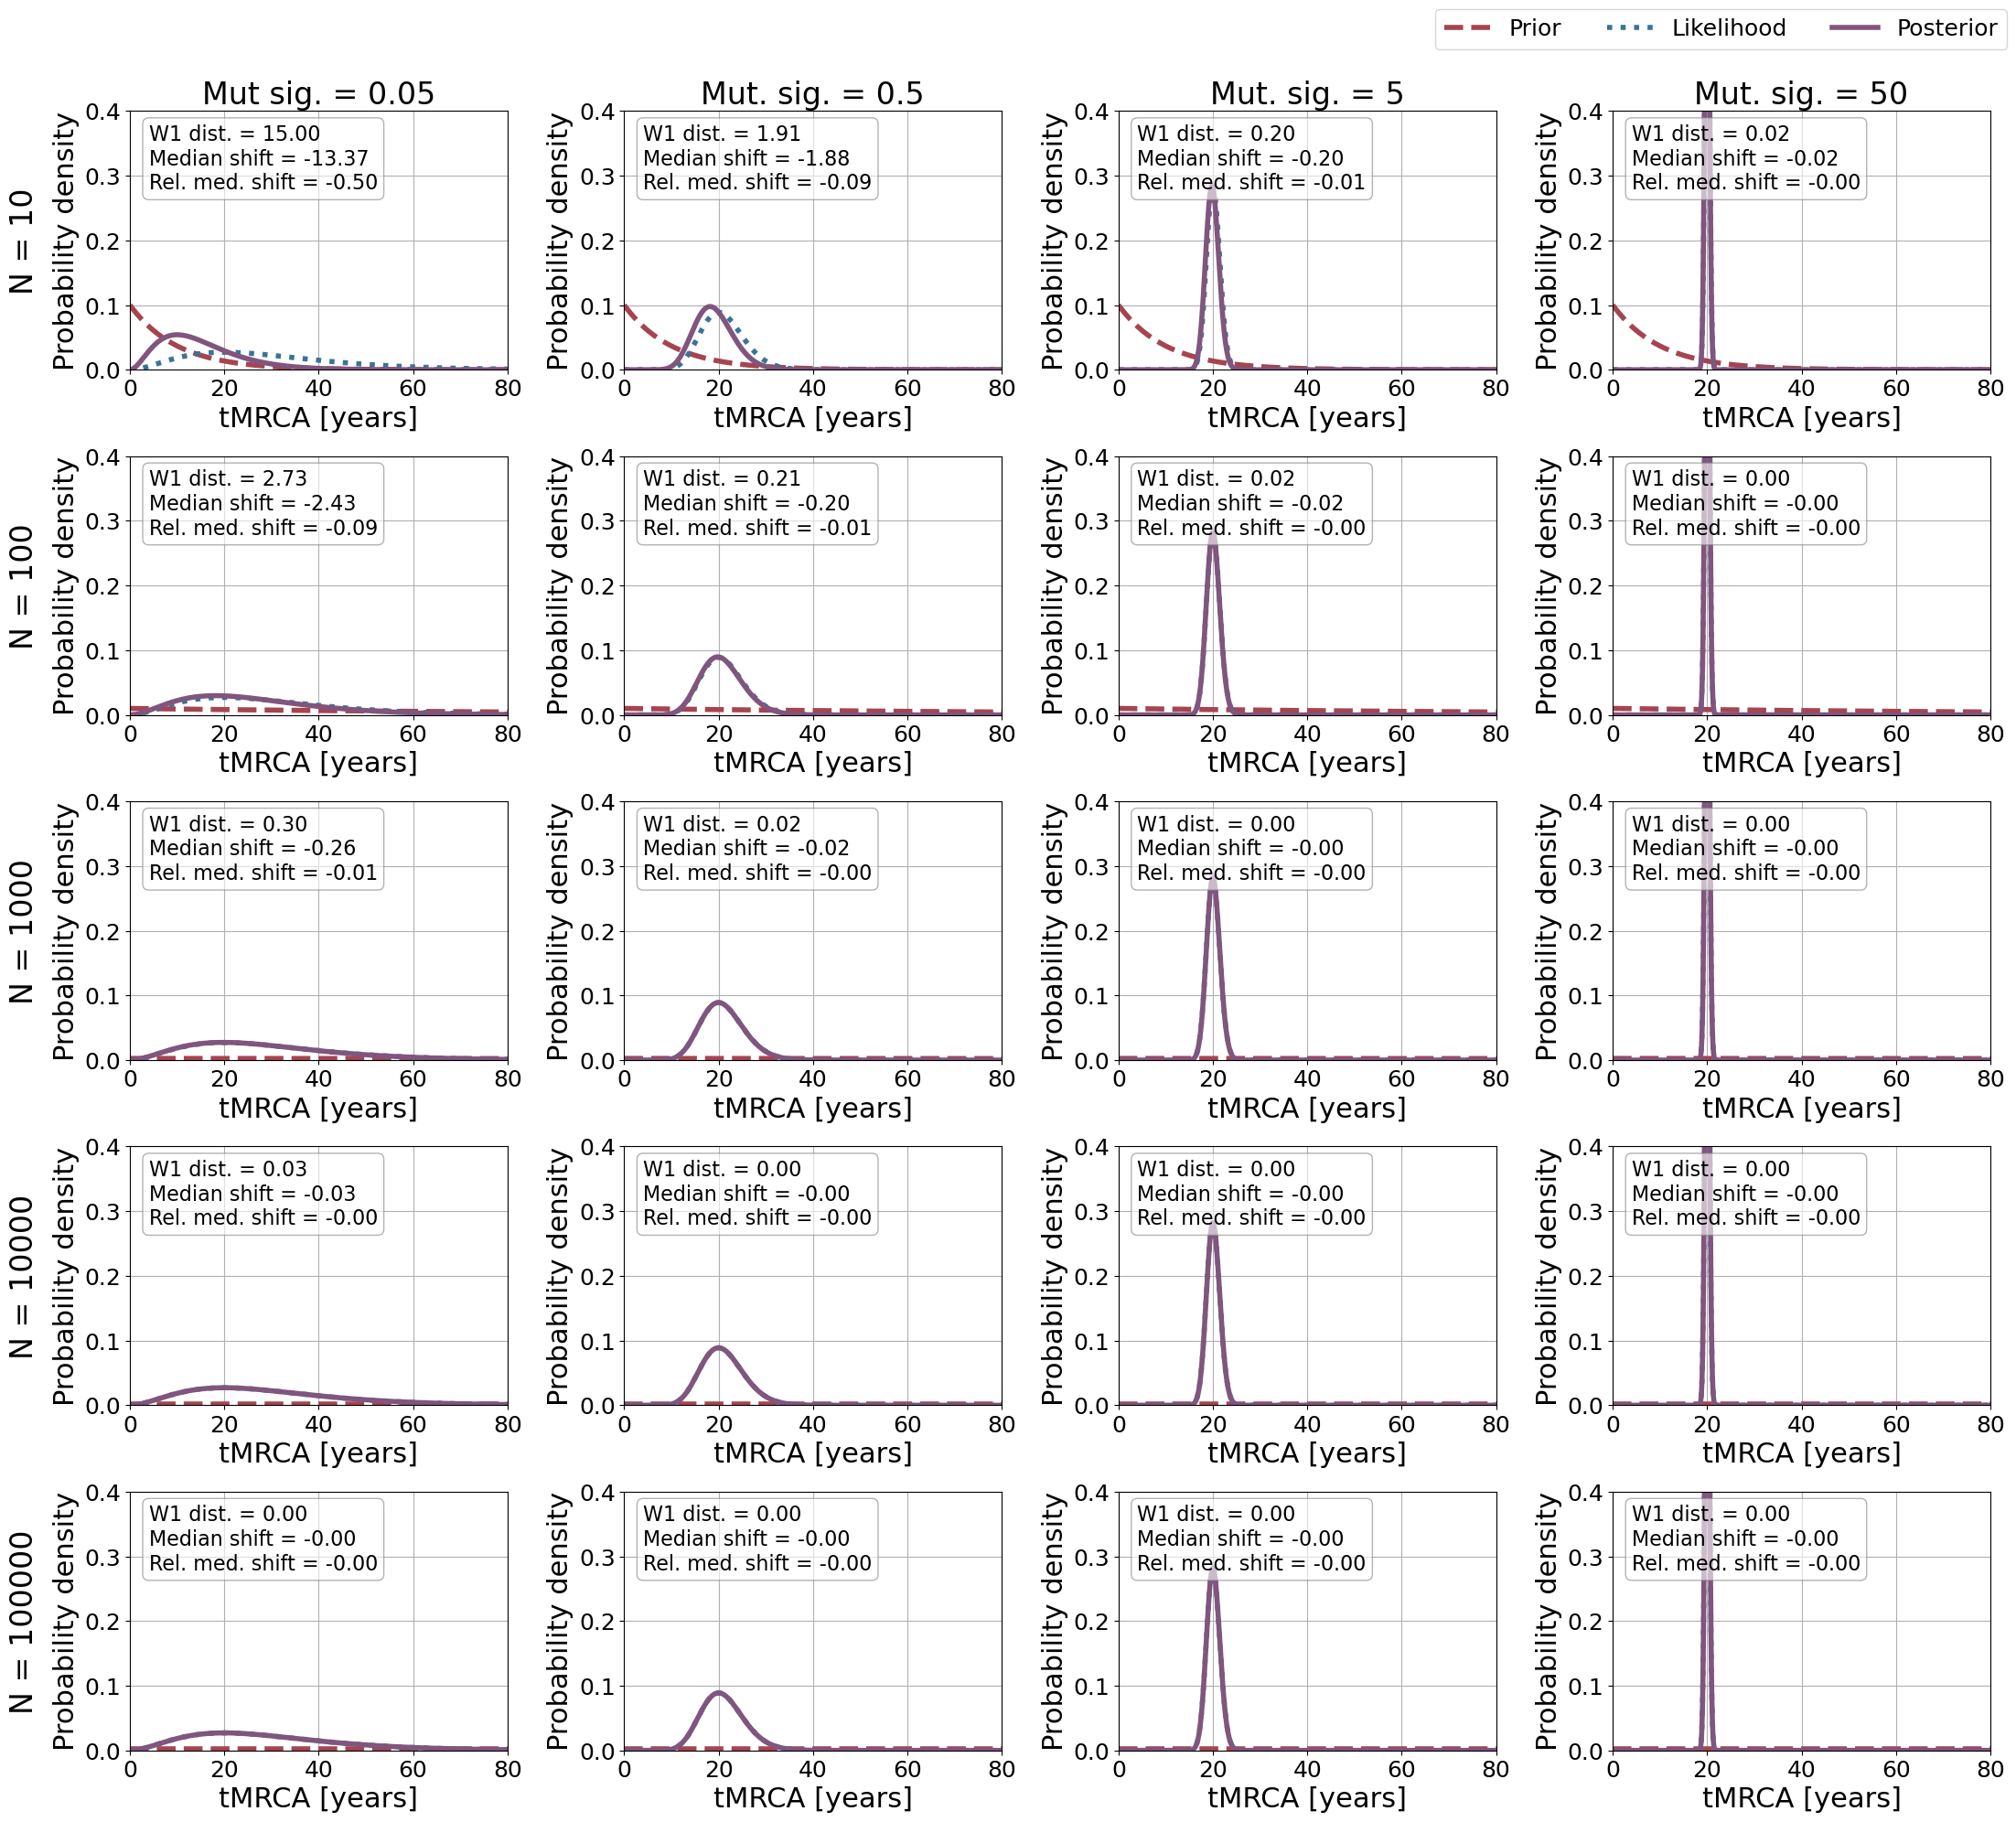

In [3]:
metrics = [
    (calculate_wasserstein_dist, "W1 dist.", {}),
    #(calculate_rel_wasserstein2_dist, "W2", {}),
    (calculate_median_shift, "Median shift", {'abs_value': False}),
    (calculate_rel_median_shift, "Rel. med. shift", {'abs_value': False}),
    #(calculate_rel_mode_shift, "Rel. mode shift", {'abs_value': True}),
    #(calculate_rel_mean_shift_const, "Rel. mean shift", {'abs_value': True}),
    #(calculate_rel_mean_shift, "Rel. mean shift numeric", {'abs_value': True}),
    #(calculate_mode_shift, "Mode shift", {'abs_value': True}),
    #(calculate_coalescent_information_ratio_at_MAP, "1 - Ω", {'reverse_scale': True}),
]

# be careful to increase time frame for metrics calculation:
# here analytic and numerical mean shift differ a lot because for the compuatation of the analytic mean shift not the whole likelihood distribution was considered (too small t_max)

#plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L, metrics=metrics, title = "Prior, Likelihood, and Posterior of tMRCA at varying population size N (rows) and varying variance of the likelihood α (columns)")
#plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L, metrics=metrics, title = "", time_scale = "years", x_max = 80, scale_mode = "max")
plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L, metrics=metrics, title = "", time_scale = "years", x_max = 80, scale_mode = "area", figsize=(22, 20), y_range = (0, 0.4),
                  column_labels = ["Mut sig. = 0.05", "Mut. sig. = 0.5", "Mut. sig. = 5", "Mut. sig. = 50"], save_path = "figures/tMRCA_constN.pdf")


beta_vec_100000 = [0.5,0.4, 0.3, 0.2, 0.1 ,0.01]
N_present = 100000
print(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_100000)*(t_MRCA_exp))*N_present}")


plot_tMRCA_expN_present(mu = base_mu * alpha_values[0], L= L, k_mut= base_k * alpha_values[0], N_present = N_present, beta_vec = beta_vec_100000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[1], L= L, k_mut= base_k * alpha_values[1], N_present = N_present, beta_vec = beta_vec_100000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[2], L= L, k_mut= base_k * alpha_values[2], N_present = N_present, beta_vec = beta_vec_100000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[3], L= L, k_mut= base_k * alpha_values[3], N_present = N_present, beta_vec = beta_vec_100000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")

beta_vec_10000 = [0.4, 0.3, 0.2, 0.1 ,0.01]
N_present = 10000
print(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_10000)*(t_MRCA_exp))*N_present}")


plot_tMRCA_expN_present(mu = base_mu * alpha_values[0], L= L, k_mut= base_k * alpha_values[0], N_present = N_present, beta_vec = beta_vec_10000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[1], L= L, k_mut= base_k * alpha_values[1], N_present = N_present, beta_vec = beta_vec_10000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[2], L= L, k_mut= base_k * alpha_values[2], N_present = N_present, beta_vec = beta_vec_10000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[3], L= L, k_mut= base_k * alpha_values[3], N_present = N_present, beta_vec = beta_vec_10000, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")


Population size 200 years ago (at expected tMRCA): [  2.47875218  18.31563889 135.33528324 367.87944117 818.73075308]


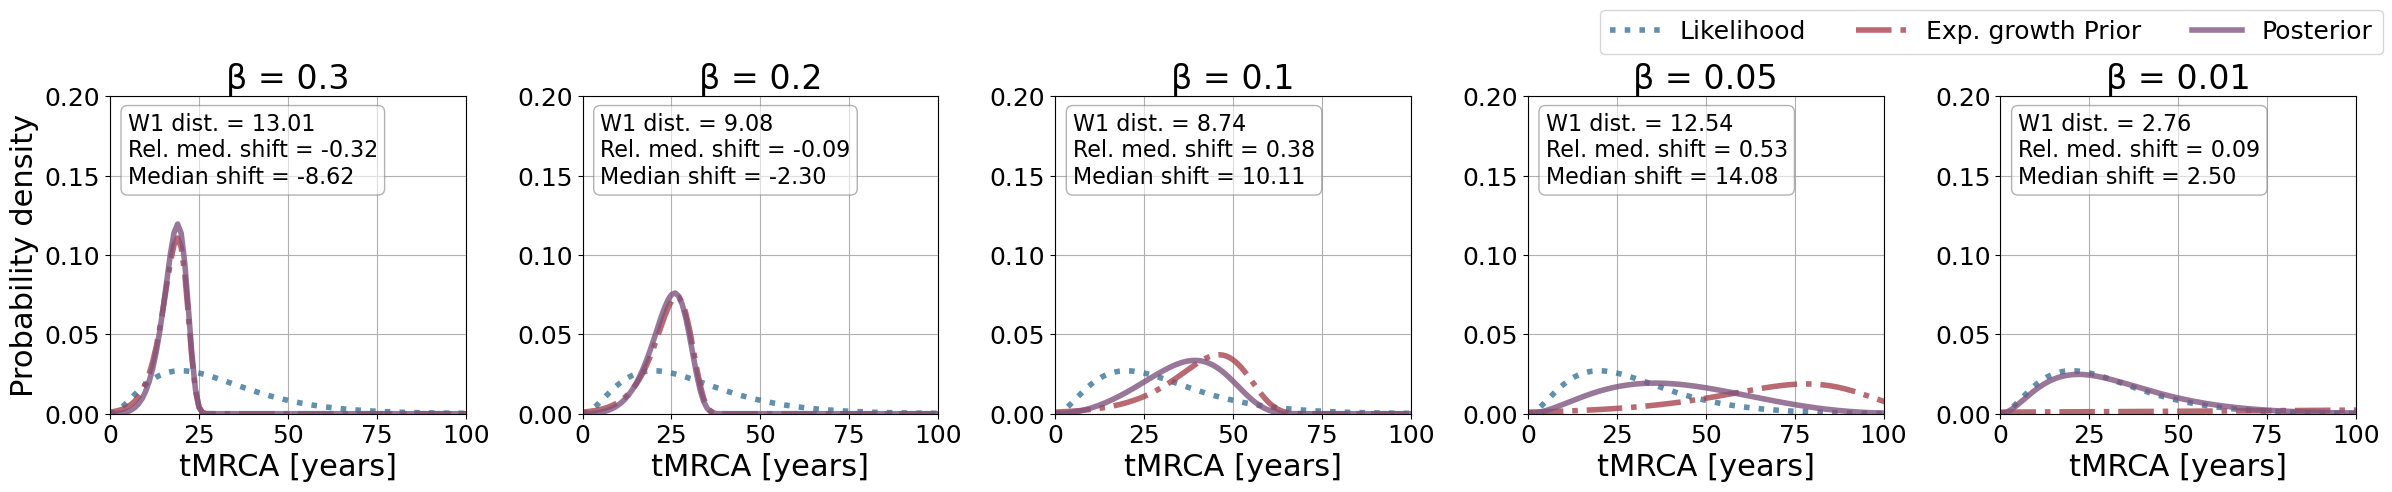

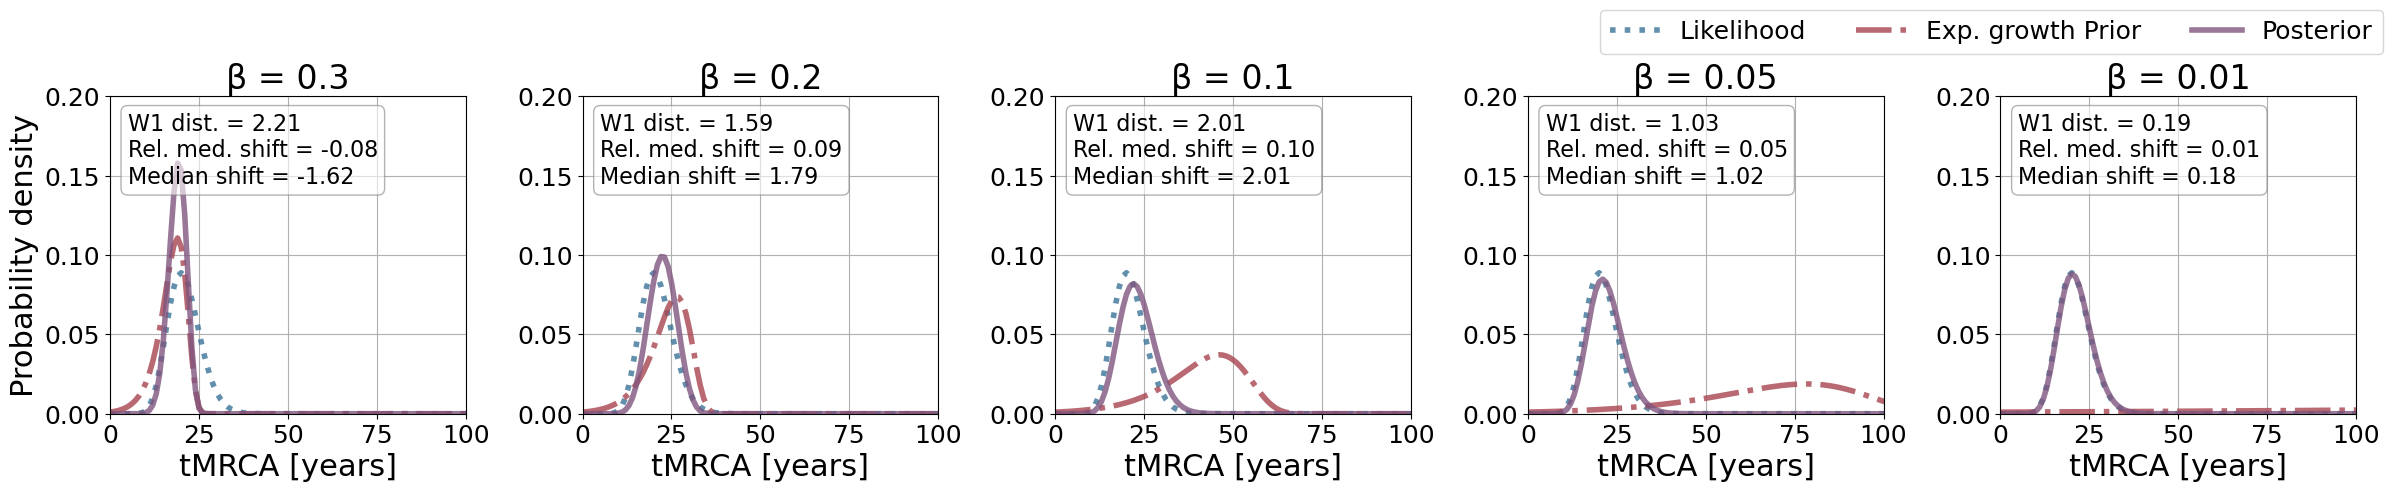

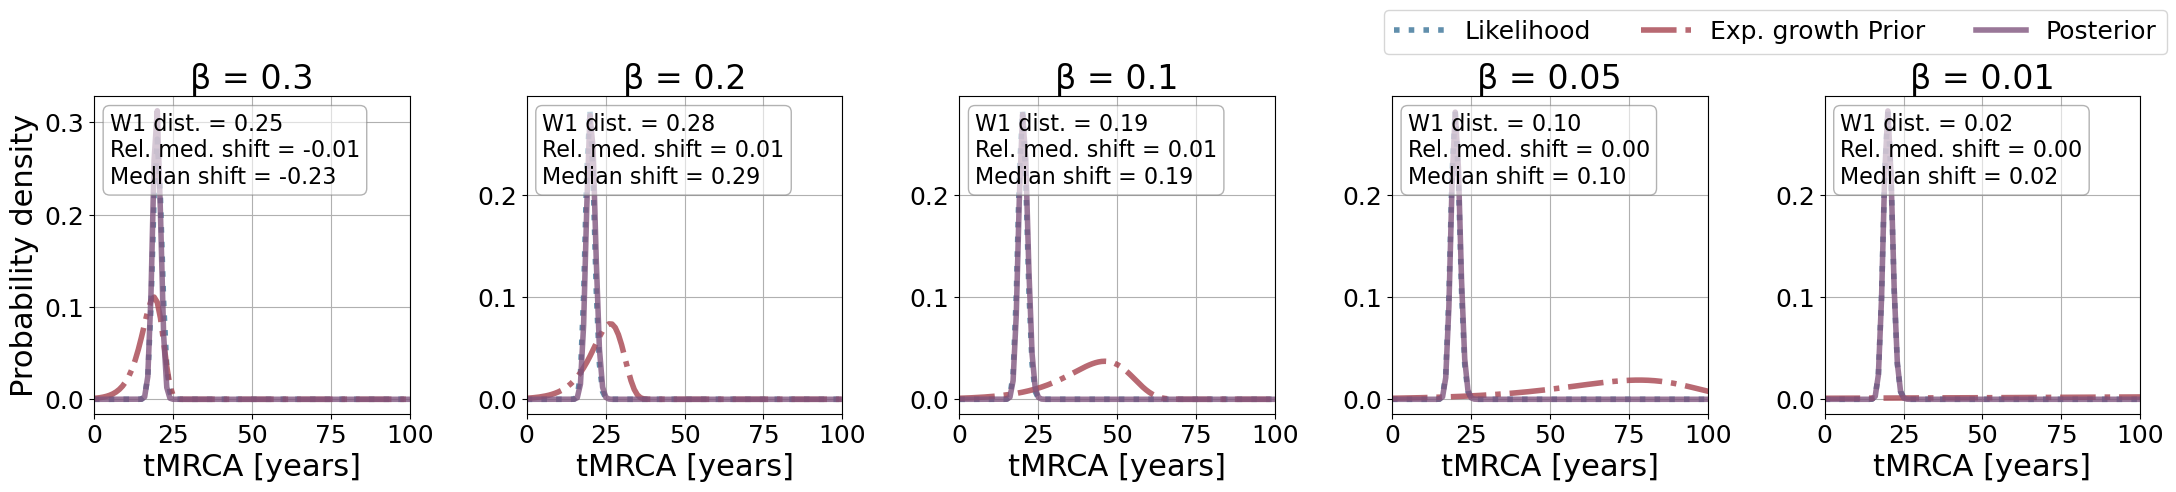

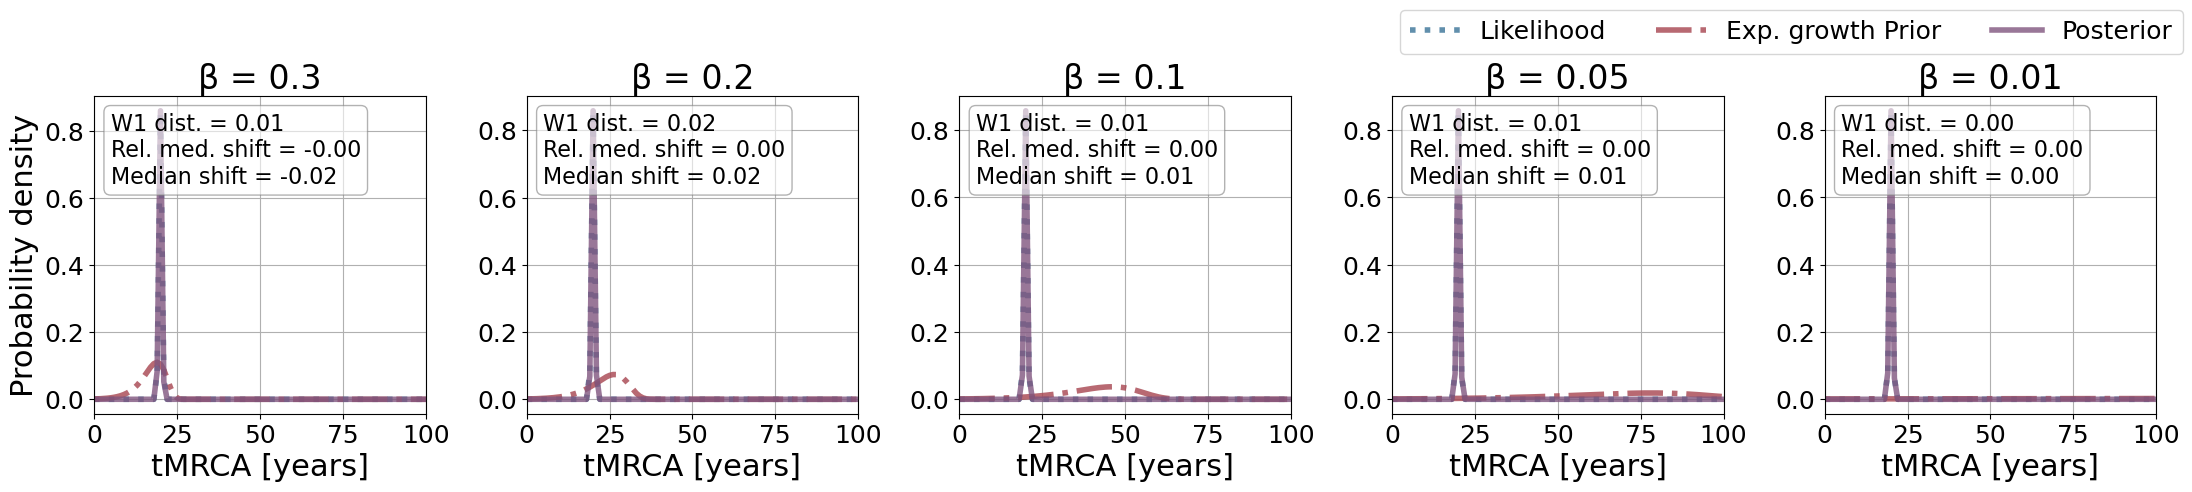

In [ ]:
metrics = [
    (calculate_wasserstein_dist, "W1 dist.", {}),
    #(calculate_rel_wasserstein2_dist, "W2", {}),
    (calculate_rel_median_shift, "Rel. med. shift", {'abs_value': False}),
    (calculate_median_shift, "Median shift", {'abs_value': False}),
    #(calculate_rel_mode_shift, "Rel. mode shift", {'abs_value': True}),
    #(calculate_rel_mean_shift_const, "Rel. mean shift", {'abs_value': True}),
    #(calculate_rel_mean_shift, "Rel. mean shift numeric", {'abs_value': True}),
    #(calculate_mode_shift, "Mode shift", {'abs_value': True}),
    #(calculate_coalescent_information_ratio_at_MAP, "1 - Ω", {'reverse_scale': True}),
]

beta_vec_1000 = [0.3, 0.2, 0.1, 0.05, 0.01]
N_present = 1000
print(f"Population size 20 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_1000)*(t_MRCA_exp))*N_present}")


plot_tMRCA_expN_present(mu = base_mu * alpha_values[0], L= L, k_mut= base_k * alpha_values[0], N_present = N_present, beta_vec = beta_vec_1000, max_tmrca = t_max, N = None, metrics= metrics, plot_comparison_to_const=False, time_scale = "years", x_max = 100, y_range = (0,0.2), scale_mode = "area", save_path = "figures/tMRCA_expN_1000_005.pdf", figsize=(24, 5))
plot_tMRCA_expN_present(mu = base_mu * alpha_values[1], L= L, k_mut= base_k * alpha_values[1], N_present = N_present, beta_vec = beta_vec_1000, max_tmrca = t_max, N = None, metrics= metrics, plot_comparison_to_const=False, time_scale = "years", x_max = 100, y_range = (0,0.2),scale_mode = "area", save_path = "figures/tMRCA_expN_1000_05.pdf", figsize=(24, 5))
plot_tMRCA_expN_present(mu = base_mu * alpha_values[2], L= L, k_mut= base_k * alpha_values[2], N_present = N_present, beta_vec = beta_vec_1000, max_tmrca = t_max, N = None, metrics= metrics, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area", figsize=(22, 5))
plot_tMRCA_expN_present(mu = base_mu * alpha_values[3], L= L, k_mut= base_k * alpha_values[3], N_present = N_present, beta_vec = beta_vec_1000, max_tmrca = t_max, N = None, metrics= metrics, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area", figsize=(22, 5))


beta_vec_100 = [0.2, 0.1, 0.05, 0.01,]
N_present = 100
print(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_100)*(t_MRCA_exp))*N_present}")


plot_tMRCA_expN_present(mu = base_mu * alpha_values[0], L= L, k_mut= base_k * alpha_values[0], N_present = N_present, beta_vec = beta_vec_100, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[1], L= L, k_mut= base_k * alpha_values[1], N_present = N_present, beta_vec = beta_vec_100, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[2], L= L, k_mut= base_k * alpha_values[2], N_present = N_present, beta_vec = beta_vec_100, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")
plot_tMRCA_expN_present(mu = base_mu * alpha_values[3], L= L, k_mut= base_k * alpha_values[3], N_present = N_present, beta_vec = beta_vec_100, max_tmrca = t_max, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 100, scale_mode = "area")


In [5]:
"""

mu_tuberculosis = 5e-8  # Approximate mutation rate for Mycobacterium tuberculosis per site per year
L_tuberculosis = 4500000  # Approximate genome length of M. tuberculosis
k_tuberculosis = 90  # Approximate number of segregating sites observed in a sample of M. tuberculosis
t_max_tuberculosis = 2000  # Maximum tMRCA to consider for M. tuberculosis, in years

beta_vec_tuberculosis = [0.03, 0.02 ,0.01, 1e-3]  # Growth rates for M. tuberculosis, in units of 1/year
N_present = 10000

print(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_tuberculosis)*200)*N_present}")
plot_tMRCA_expN_present(mu = mu_tuberculosis, L= L_tuberculosis, k_mut= k_tuberculosis, N_present = N_present, beta_vec = beta_vec_tuberculosis, max_tmrca = t_max_tuberculosis, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 500, scale_mode = "max")
plot_tMRCA_expN_present(mu = mu_tuberculosis, L= L_tuberculosis, k_mut= k_tuberculosis, N_present = N_present, beta_vec = beta_vec_tuberculosis, max_tmrca = t_max_tuberculosis, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 500, scale_mode = "area")

beta_vec_tuberculosis = [0.02,  0.01, 0.008,0.005, 1e-3,]  # Growth rates for M. tuberculosis, in units of 1/year
N_present = 1000

print(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_tuberculosis)*200)*N_present}")
plot_tMRCA_expN_present(mu = mu_tuberculosis, L= L_tuberculosis, k_mut= k_tuberculosis, N_present = N_present, beta_vec = beta_vec_tuberculosis, max_tmrca = t_max_tuberculosis, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 500, scale_mode = "max")
plot_tMRCA_expN_present(mu = mu_tuberculosis, L= L_tuberculosis, k_mut= k_tuberculosis, N_present = N_present, beta_vec = beta_vec_tuberculosis, max_tmrca = t_max_tuberculosis, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 500, scale_mode = "area")
"""

'\n\nmu_tuberculosis = 5e-8  # Approximate mutation rate for Mycobacterium tuberculosis per site per year\nL_tuberculosis = 4500000  # Approximate genome length of M. tuberculosis\nk_tuberculosis = 90  # Approximate number of segregating sites observed in a sample of M. tuberculosis\nt_max_tuberculosis = 2000  # Maximum tMRCA to consider for M. tuberculosis, in years\n\nbeta_vec_tuberculosis = [0.03, 0.02 ,0.01, 1e-3]  # Growth rates for M. tuberculosis, in units of 1/year\nN_present = 10000\n\nprint(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array(beta_vec_tuberculosis)*200)*N_present}")\nplot_tMRCA_expN_present(mu = mu_tuberculosis, L= L_tuberculosis, k_mut= k_tuberculosis, N_present = N_present, beta_vec = beta_vec_tuberculosis, max_tmrca = t_max_tuberculosis, N = None, plot_comparison_to_const=False, time_scale = "years", x_max = 500, scale_mode = "max")\nplot_tMRCA_expN_present(mu = mu_tuberculosis, L= L_tuberculosis, k_mut= k_tuberculosis, N_present = N_pres

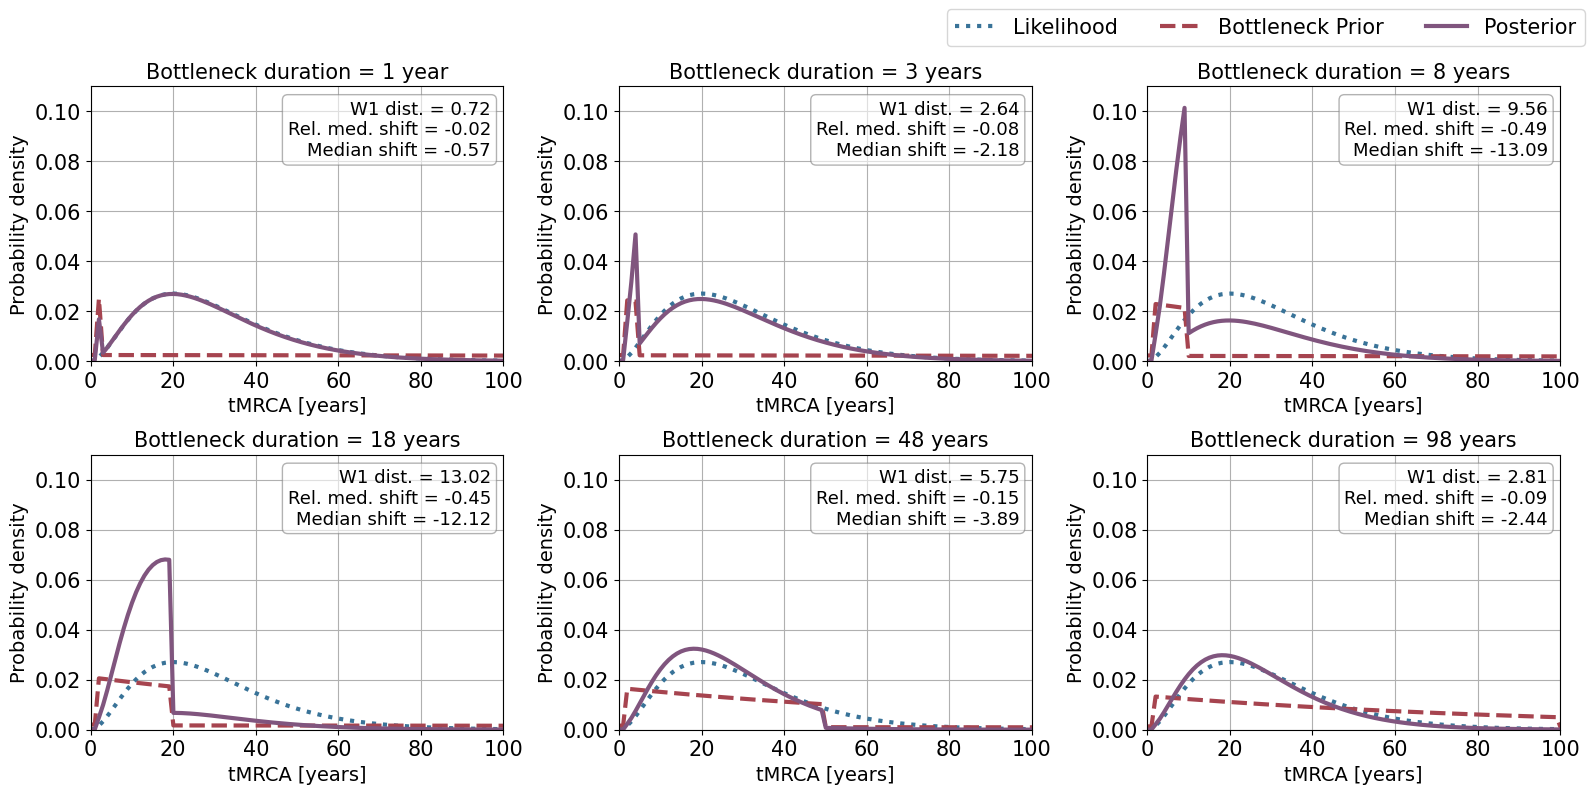

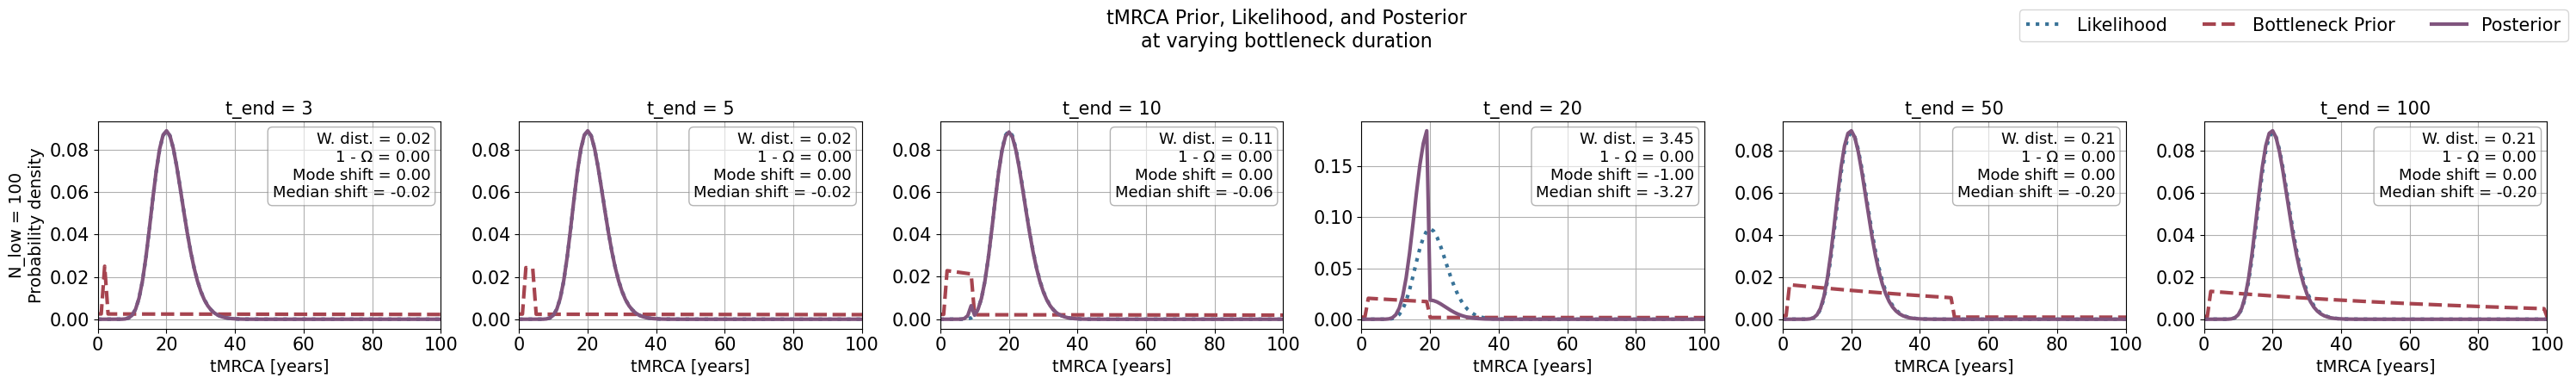

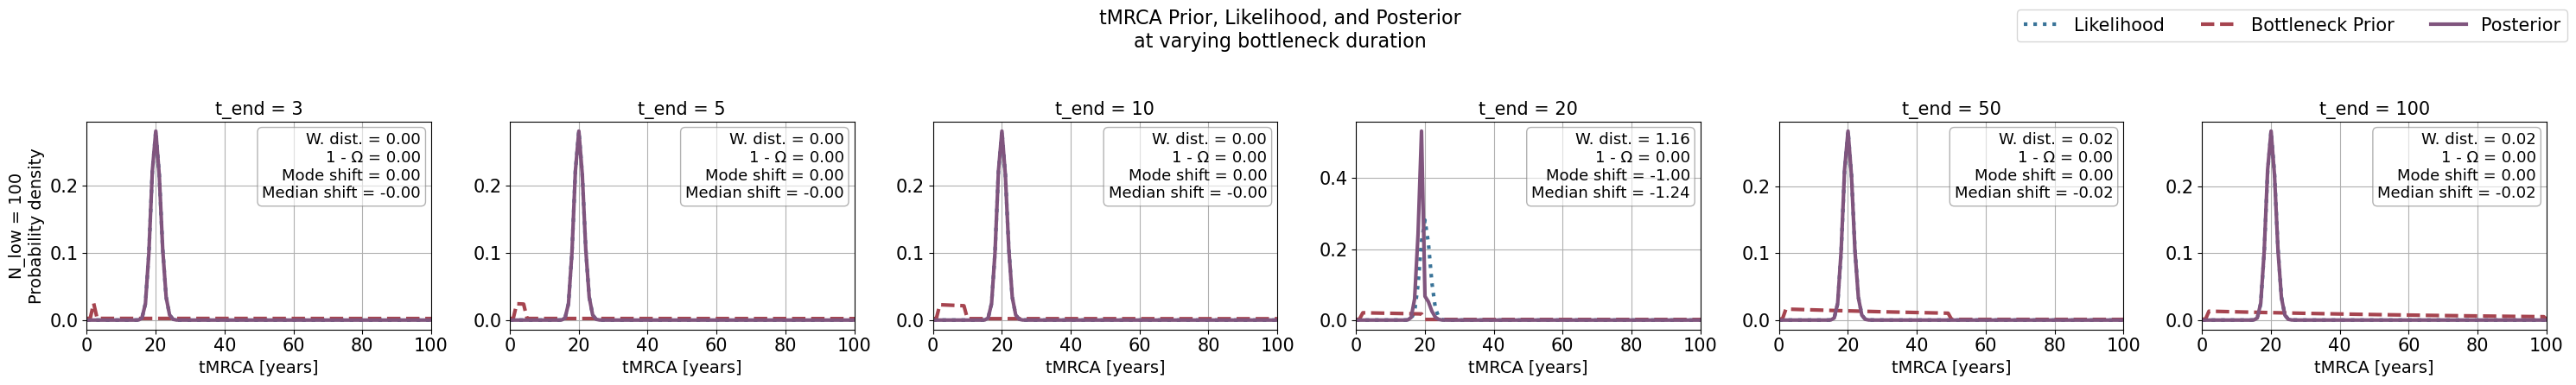

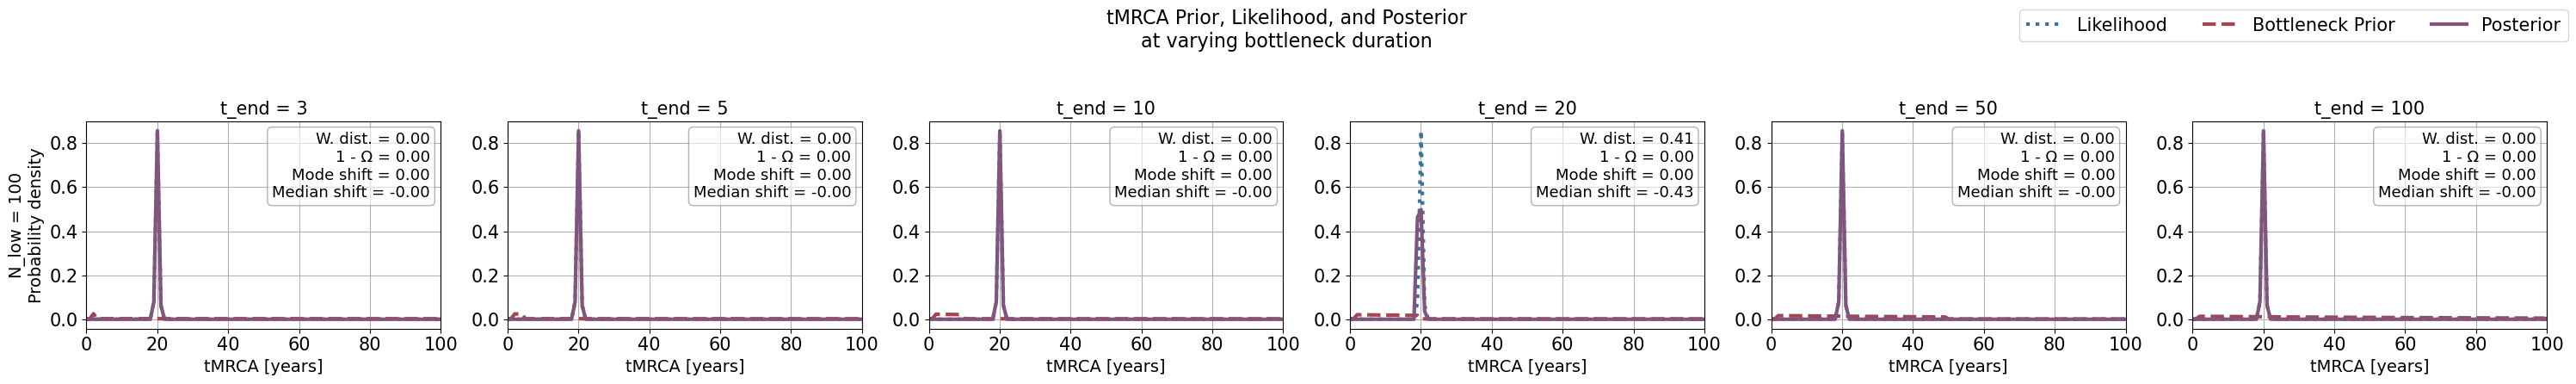

In [6]:
plot_tMRCA_bottleneck(base_mu * alpha_values[0], L, base_k * alpha_values[0], 1000, [100], 2, [3, 5, 10, 20, 50, 100], t_max, time_scale='years', x_max = 100, scale_mode = "area", figsize = (16,8), max_cols = 3,
                      title = "", metrics = metrics, save_path = "figures/tMRCA_bottleneck_005.pdf", y_range = (0, 0.11),
                      tile_labels = ["Bottleneck duration = 1 year", "Bottleneck duration = 3 years", "Bottleneck duration = 8 years", "Bottleneck duration = 18 years", "Bottleneck duration = 48 years", "Bottleneck duration = 98 years"])
plot_tMRCA_bottleneck(base_mu * alpha_values[1], L, base_k * alpha_values[1], 1000, [100], 2, [3, 5, 10, 20, 50, 100], t_max, time_scale='years', x_max = 100, scale_mode = "area")
plot_tMRCA_bottleneck(base_mu * alpha_values[2], L, base_k * alpha_values[2], 1000, [100], 2, [3, 5, 10,20, 50, 100], t_max, time_scale='years', x_max = 100, scale_mode = "area")
plot_tMRCA_bottleneck(base_mu * alpha_values[3], L, base_k * alpha_values[3], 1000, [100], 2, [3, 5, 10, 20, 50, 100], t_max, time_scale='years', x_max = 100, scale_mode = "area")


## Summary plots

In [7]:
pathogen_params = {
    "0.05 (part of bacterial genome)":
    {
        "N_values": [10, 100, 1000, 10000, 100000],
        "mu": base_mu * 0.01,
        "k": base_k * 0.01,
        "L": L,
        "t_max": t_max,
    },
    "0.5 (bacterial genome)":
    {
        "N_values": [10, 100, 1000, 10000, 100000],
        "mu": base_mu * 0.1,
        "k": base_k * 0.1,
        "L": L,
        "t_max": t_max,
    },
    "5 (typical RNA virus gene)":
    {
        "N_values": [10, 100, 1000, 10000, 100000],
        "mu": base_mu,
        "k": base_k,
        "L": L,
        "t_max": t_max,
    },
    "50 (upper bound for RNA virus genome)":
    {
        "N_values": [10, 100, 1000, 10000, 100000],
        "mu": base_mu * 10,
        "k": base_k * 10,
        "L": L,
        "t_max": t_max,
    }
}

In [8]:
pathogen_const_df = create_prior_influence_metric_df_const_pathogen(pathogen_params)
pathogen_exp_growth_df = create_prior_influence_metric_df_exp_pathogen(pathogen_params, N = 1000, beta_vec = [0.3, 0.2, 0.15, 0.1, 0.09, 0.08,0.07,0.06, 0.05, 0.04, 0.03, 0.02,0.01])
pathogen_bottleneck_df = create_prior_influence_metric_df_bottleneck_pathogen(pathogen_params, N_high = 1000, N_low = 100, t_bottleneck_end_vec = [3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], t_bottleneck_start = 2)

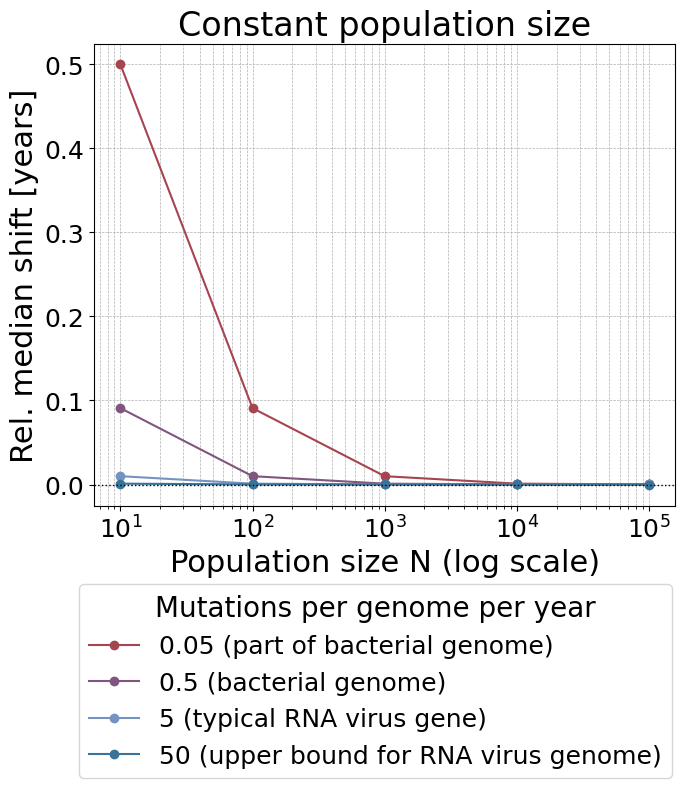

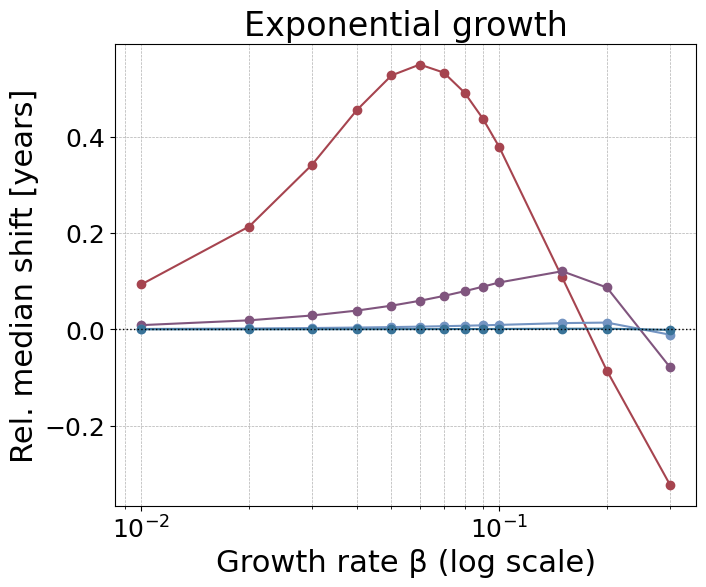

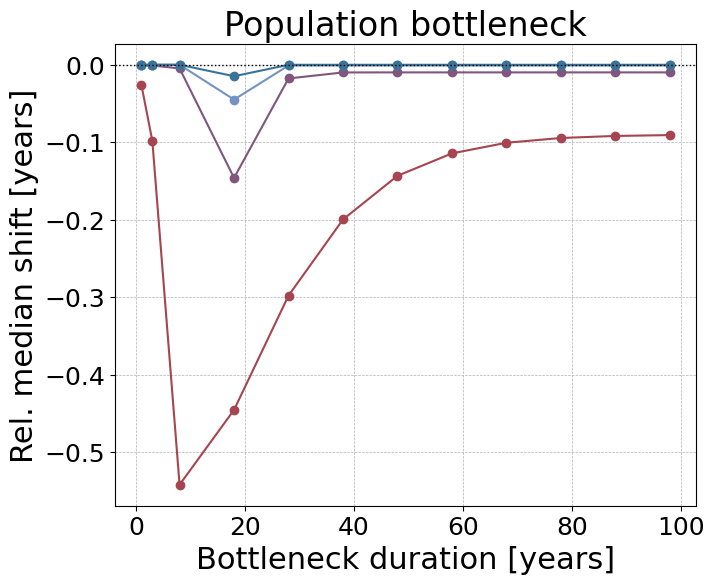

In [12]:
plot_pathogen_error_summary(df_const = pathogen_const_df, title = "", error_col="rel_median_shift", y_label = "Rel. median shift [years]", legend_position="below", save_path = "figures/pathogen_error_summary_const.pdf")
plot_pathogen_error_summary(df_growth =pathogen_exp_growth_df, title = "", error_col="rel_median_shift", y_label = "Rel. median shift [years]", legend_position="none", save_path = "figures/pathogen_error_summary_growth.pdf")
plot_pathogen_error_summary(df_bottleneck = pathogen_bottleneck_df, title = "", error_col="rel_median_shift", y_label = "Rel. median shift [years]", legend_position="none", save_path = "figures/pathogen_error_summary_bottleneck.pdf")

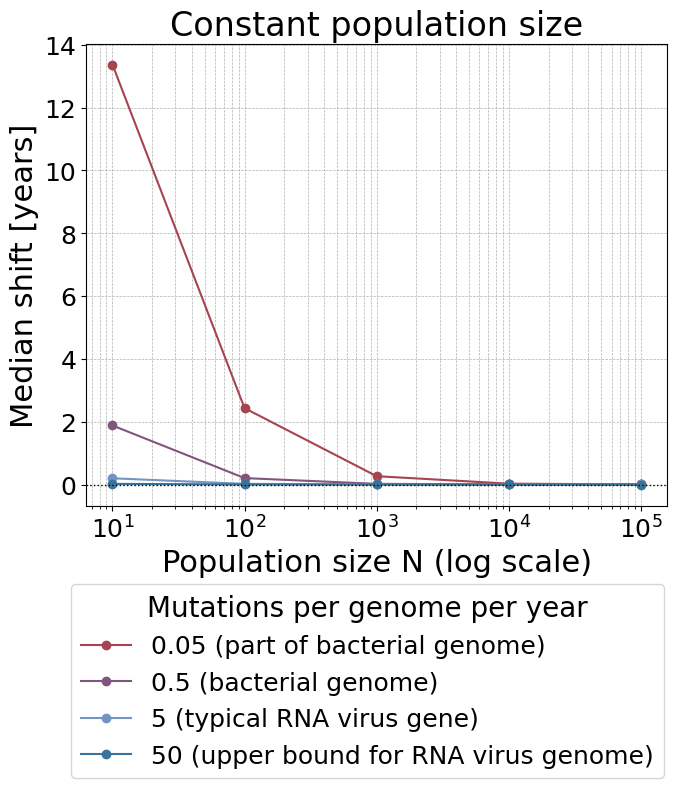

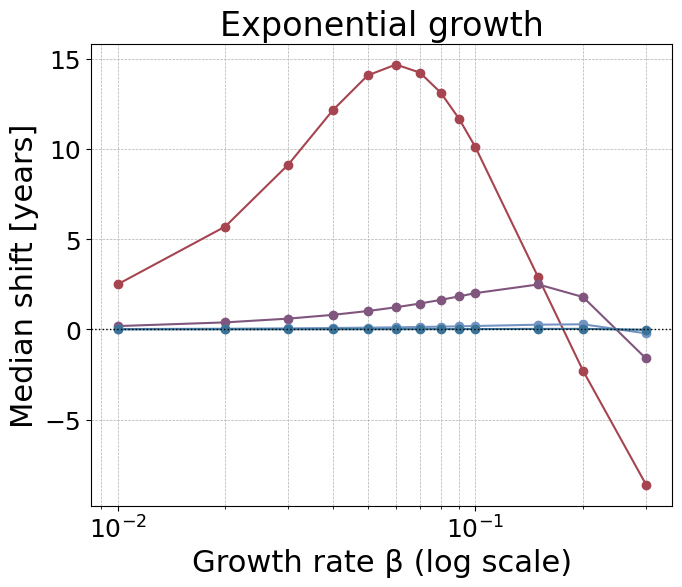

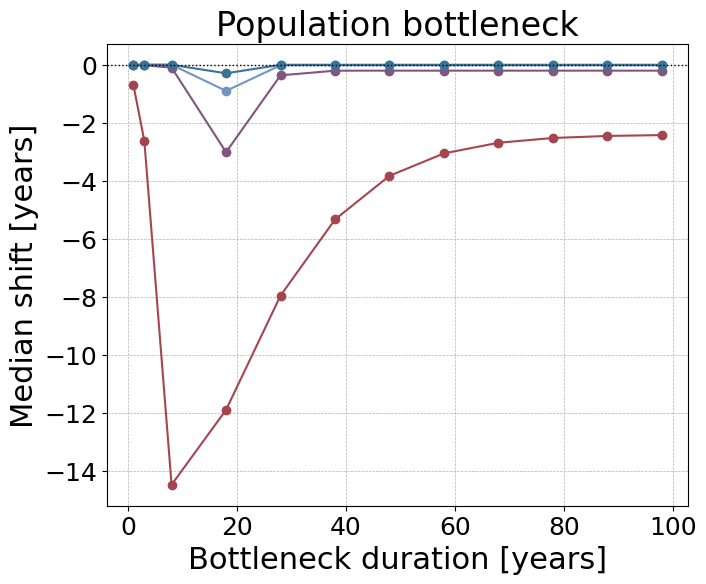

In [18]:
plot_pathogen_error_summary(df_const = pathogen_const_df, title = "", error_col="median_shift", y_label = "Median shift [years]", legend_position="below", save_path = "figures/pathogen_error_summary_const_median.pdf")
plot_pathogen_error_summary(df_growth =pathogen_exp_growth_df, title = "", error_col="median_shift", y_label = "Median shift [years]", legend_position="none", save_path = "figures/pathogen_error_summary_growth_median.pdf")
plot_pathogen_error_summary(df_bottleneck = pathogen_bottleneck_df, title = "", error_col="median_shift", y_label = "Median shift [years]", legend_position="none", save_path = "figures/pathogen_error_summary_bottleneck_median.pdf")

In [19]:
pathogen_const_df

,pathogen,N,rel_mean_shift,rel_mode_shift,rel_median_shift,mode_shift,median_shift,wasserstein_dist,wasserstein2_dist,reverse_coalescent_information_ratio_at_MAP
0,0.05 (part of bacterial genome),10,5.000000e-01,0.50,4.999973e-01,10.00200,13.370254,15.000000,17.301940,2.929286e-01
1,0.05 (part of bacterial genome),100,9.090909e-02,0.09,9.090968e-02,1.80036,2.430984,2.727273,3.145808,8.979411e-03
2,0.05 (part of bacterial genome),1000,9.900990e-03,0.01,9.901054e-03,0.20004,0.264761,0.297030,0.342613,9.900510e-05
3,0.05 (part of bacterial genome),10000,9.990010e-04,0.00,9.997052e-04,0.00000,0.026733,0.029970,0.034569,1.000199e-06
4,0.05 (part of bacterial genome),100000,9.999000e-05,0.00,1.000299e-04,0.00000,0.002675,0.003000,0.003460,1.000200e-08
5,0.5 (bacterial genome),10,9.090909e-02,0.09,9.090941e-02,1.80036,1.878887,1.909091,1.953388,8.021870e-02
6,0.5 (bacterial genome),100,9.900990e-03,0.01,9.900840e-03,0.20004,0.204627,0.207921,0.212745,9.887297e-04
7,0.5 (bacterial genome),1000,9.990010e-04,0.00,9.988543e-04,0.00000,0.020644,0.020979,0.021465,1.000185e-05
8,0.5 (bacterial genome),10000,9.999000e-05,0.00,9.994585e-05,0.00000,0.002066,0.002100,0.002148,1.000200e-07
9,0.5 (bacterial genome),100000,9.999900e-06,0.00,9.995196e-06,0.00000,0.000207,0.000210,0.000215,1.000200e-09


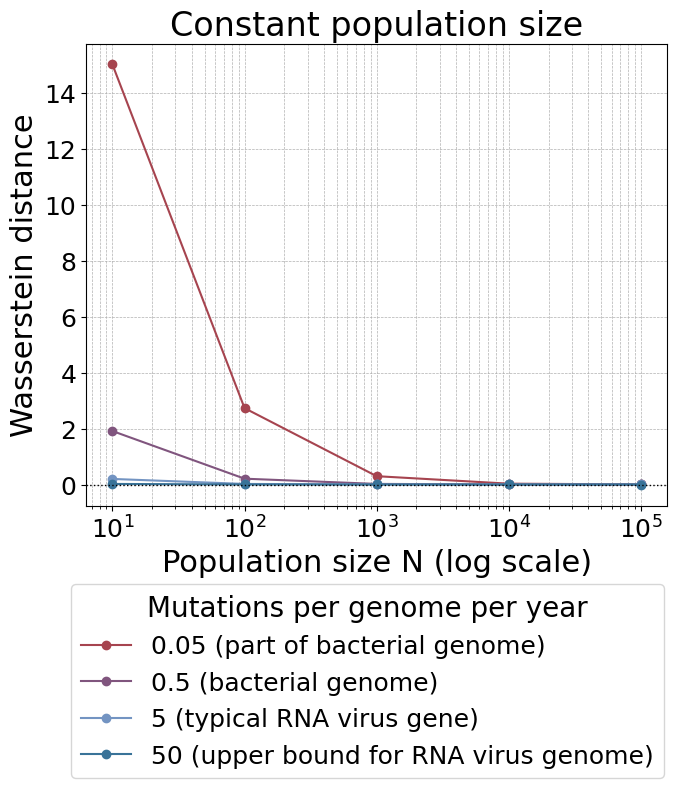

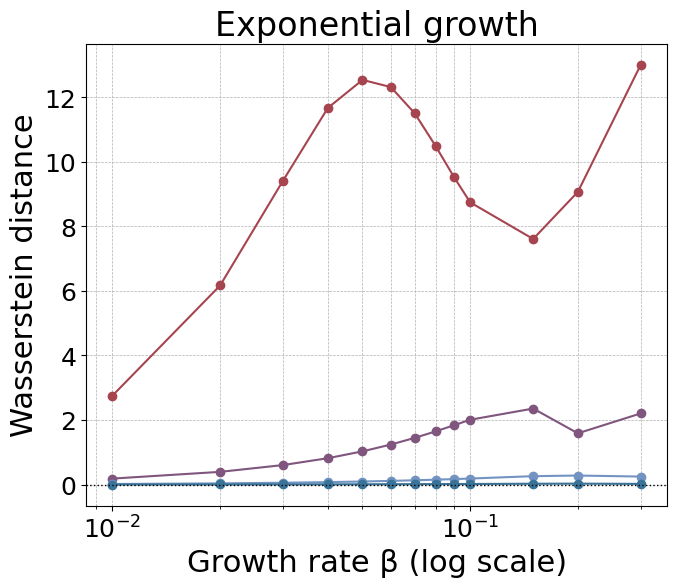

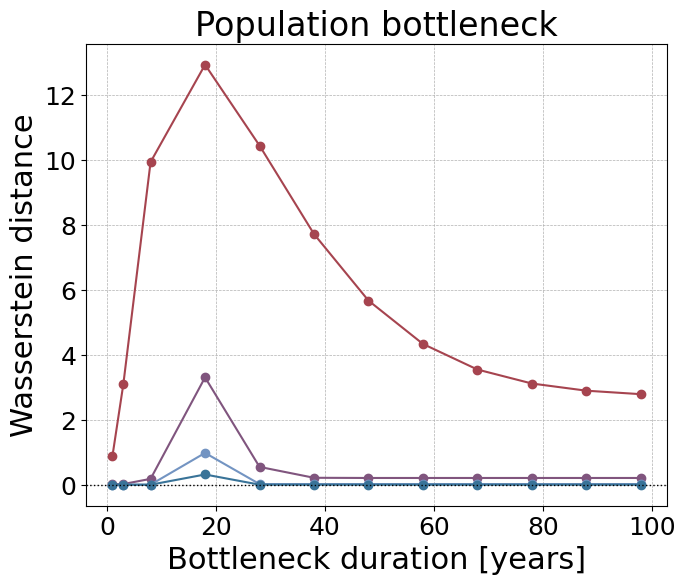

In [20]:
plot_pathogen_error_summary(df_const = pathogen_const_df, title = "", error_col="wasserstein_dist", y_label = "Wasserstein distance", legend_position="below", save_path = "figures/pathogen_error_summary_const_wasserstein.pdf")
plot_pathogen_error_summary(df_growth =pathogen_exp_growth_df, title = "", error_col="wasserstein_dist", y_label = "Wasserstein distance", legend_position="none", save_path = "figures/pathogen_error_summary_growth_wasserstein.pdf")
plot_pathogen_error_summary(df_bottleneck = pathogen_bottleneck_df, title = "", error_col="wasserstein_dist", y_label = "Wasserstein distance", legend_position="none", save_path = "figures/pathogen_error_summary_bottleneck_wasserstein.pdf")

In [10]:
# fix 0.5 mutations per genome per year (a bit higher signal than tuberculosis setting)
N_beta = {100: [0.2, 0.15, 0.1, 0.09, 0.08,0.07,0.06, 0.05, 0.04, 0.03, 0.02,0.01], 1000: [0.3, 0.2, 0.15, 0.1, 0.09, 0.08,0.07,0.06, 0.05, 0.04, 0.03, 0.02,0.01], 10000:[0.4, 0.3, 0.2, 0.15, 0.1, 0.09, 0.08,0.07,0.06, 0.05, 0.04, 0.03, 0.02,0.01], 100000:[0.5,0.4, 0.3, 0.2, 0.15, 0.1, 0.09, 0.08,0.07,0.06, 0.05, 0.04, 0.03, 0.02,0.01]}

exp_tuberculosis_df = create_prior_influence_metric_df_pathogen_exp(N_beta, base_mu * alpha_values[1], base_k * alpha_values[1], L, t_max)
exp_tuberculosis_df

tuberculosis_bottleneck_df = create_prior_influence_metric_df_bottleneck(N_high = 1000, N_low_values = [100, 300, 500, 800], t_bottleneck_end_vec = [3, 5, 10, 20, 30, 40, 50,], t_bottleneck_start = 2, alpha_values = [0.1], base_mu = base_mu, base_k = base_k, L = L, t_max = t_max)

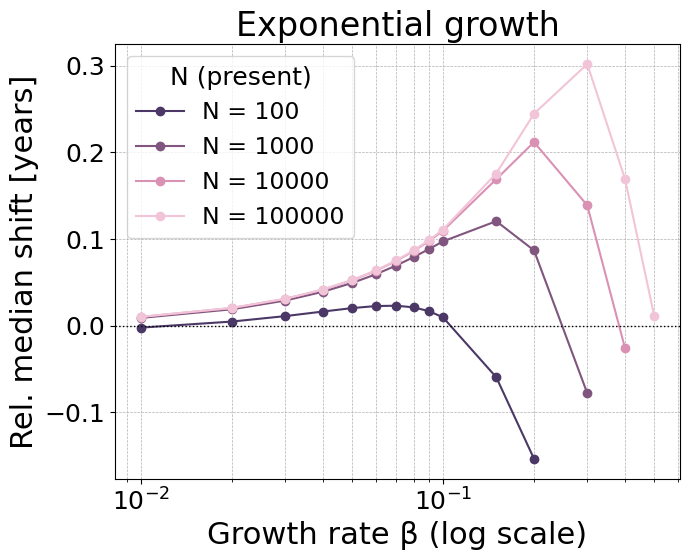

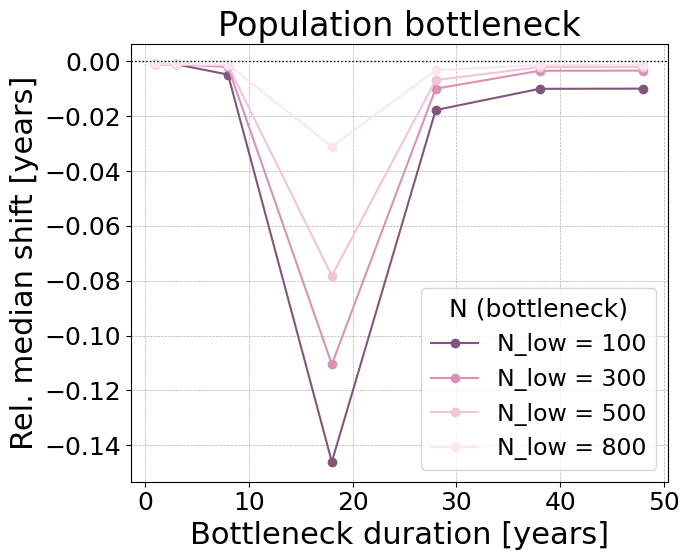

In [15]:
plot_metric_summary(df_exp = exp_tuberculosis_df, title = "Median shift comparison for different population size models", metric = 'rel_median_shift', y_label = "Rel. median shift [years]", legend_title = "N (present)", save_path = "figures/rel_median_shift_comparison_exp.pdf")
plot_metric_summary(df_bottleneck = tuberculosis_bottleneck_df, title = "Median shift comparison for different population size models", metric = 'rel_median_shift', y_label = "Rel. median shift [years]", legend_title = "N (bottleneck)", save_path = "figures/rel_median_shift_comparison_bottleneck.pdf")

In [23]:
exp_tuberculosis_df

,N_present,beta,rel_mean_shift,rel_mode_shift,rel_median_shift,wasserstein_dist,wasserstein_dist2,r_coalescent_information_ratio_at_MAP,mode_shift,median_shift
0,100,0.20,-0.169398,-0.120,-0.153912,3.557357,4.076350,0.234363,-2.40048,-3.180998
1,100,0.15,-0.073054,-0.030,-0.059652,1.540394,1.996257,0.166240,-0.60012,-1.232878
2,100,0.10,0.002452,0.025,0.009499,0.342411,0.460552,0.089814,0.50010,0.196313
3,100,0.09,0.011044,0.025,0.016597,0.345989,0.396945,0.074761,0.50010,0.343013
4,100,0.08,0.016868,0.030,0.021047,0.388386,0.411293,0.060909,0.60012,0.434986
5,100,0.07,0.019958,0.030,0.022957,0.426383,0.436525,0.047844,0.60012,0.474471
6,100,0.06,0.020514,0.025,0.022563,0.431809,0.435432,0.035902,0.50010,0.466321
7,100,0.05,0.018859,0.020,0.020187,0.396114,0.397490,0.025515,0.40008,0.417224
8,100,0.04,0.015372,0.020,0.016184,0.322807,0.323883,0.016905,0.40008,0.334484
9,100,0.03,0.010435,0.010,0.010896,0.219145,0.220046,0.009951,0.20004,0.225199


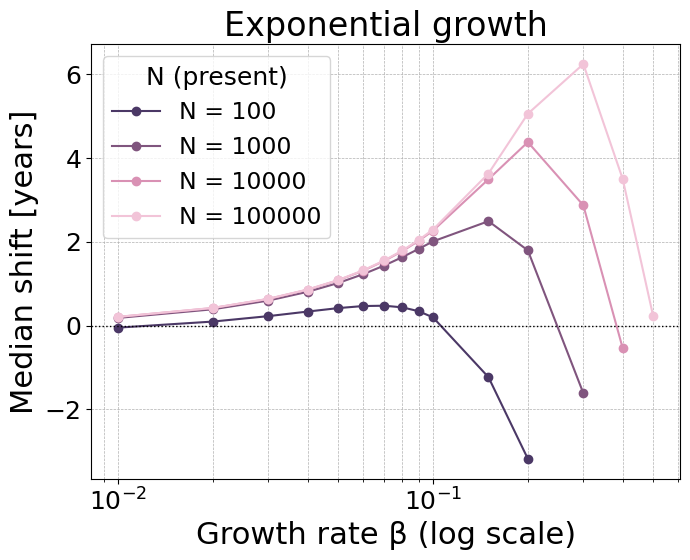

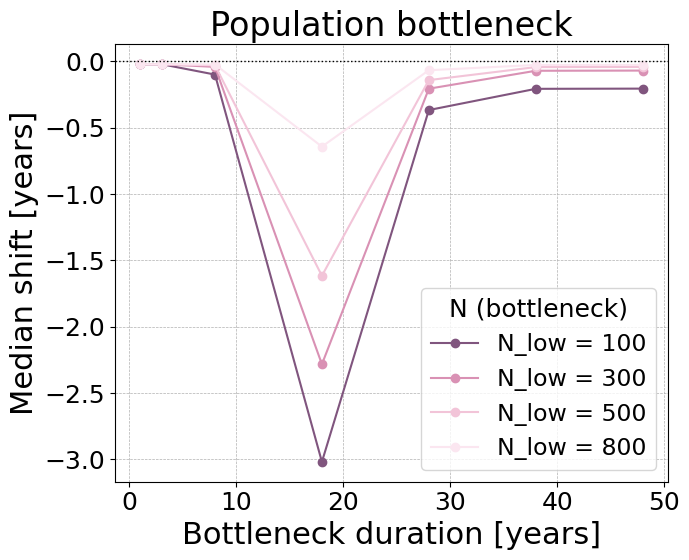

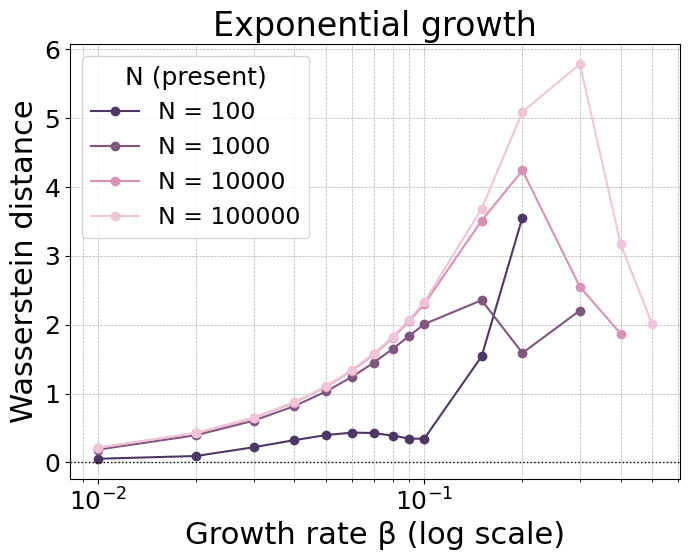

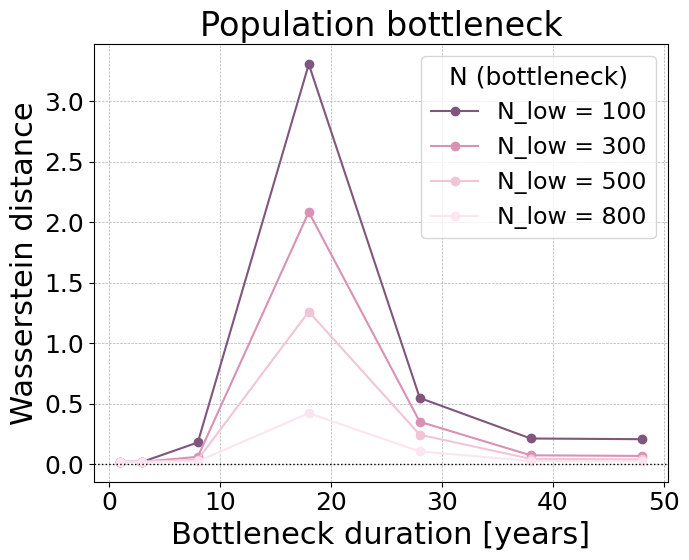

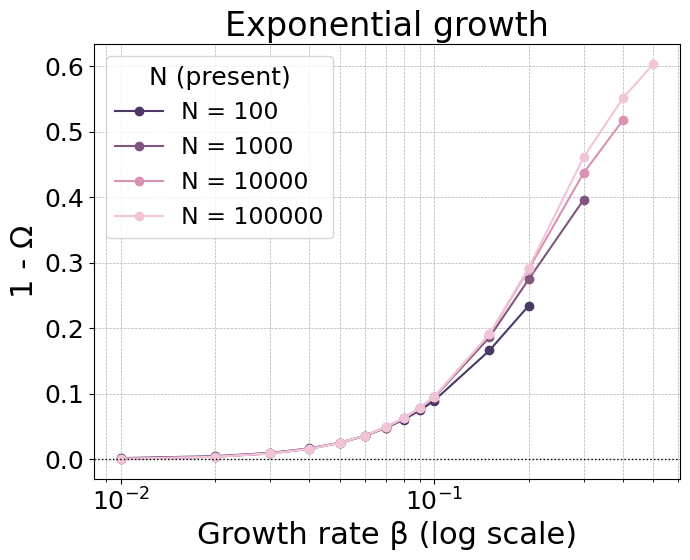

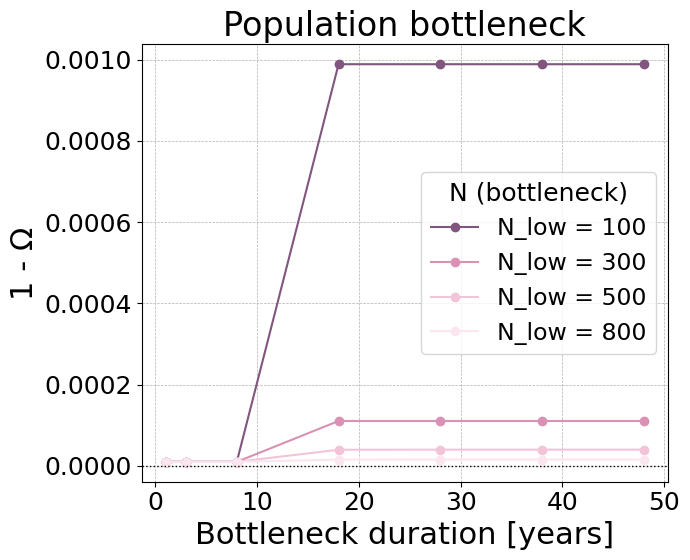

In [ ]:
plot_metric_summary(df_exp = exp_tuberculosis_df, title = "Median shift comparison for different population size models", metric = 'median_shift', y_label = "Median shift [years]", legend_title = "N (present)", save_path = "figures/median_shift_comparison_exp.pdf")
plot_metric_summary(df_bottleneck = tuberculosis_bottleneck_df, title = "Median shift comparison for different population size models", metric = 'median_shift', y_label = "Median shift [years]", legend_title = "N (bottleneck)", save_path = "figures/median_shift_comparison_bottleneck.pdf")

plot_metric_summary(df_exp = exp_tuberculosis_df, title = "Wasserstein distance comparison for different population size models", metric = 'wasserstein_dist', y_label = "Wasserstein distance", legend_title = "N (present)", save_path = "figures/wasserstein_comparison_exp.pdf")
plot_metric_summary(df_bottleneck = tuberculosis_bottleneck_df, title = "Wasserstein distance comparison for different population size models", metric = 'wasserstein_dist', y_label = "Wasserstein distance", legend_title = "N (bottleneck)", save_path = "figures/wasserstein_comparison_bottleneck.pdf")